# Q12, Q13 & Q14 -- Bond Sensitivity, Hedging Strategy, Implementation
**SMM269 Fixed Income | UniCredit IT0005599110**

| Question | Topic |
|---|---|
| **Q12** | Bond sensitivity to +/-1-sigma PCA factor shocks |
| **Q13** | Factor-neutral IRS hedge -- hedge ratios via linear system |
| **Q14** | Implementation at full issue scale, residual risk, transaction costs |

**Methodology**

The sensitivity procedure:
1. Extract implied par swap rates at the 8 tenor nodes from the base DF grid.
2. Apply a shift to swap rate nodes: `delta_IRS_j = v_kj * delta_PC_k`.
3. Re-bootstrap annual discount factors from the shifted swap rates (annual fixed leg, EUR).
4. Interpolate log-linearly to the full daily TTM grid.
5. Reprice the bond on the new curve; central-finite-difference gives the DV01.

**Hedge instruments:** IRS 1Y, 5Y, 10Y (annual fixed leg, EUR). Chosen to span the short (1Y), medium (5Y) and long (10Y) ends of the curve, maximising linear independence across the three PCA factors. The 1Y swap has the largest slope and curvature eigenvector loadings.

**Prerequisites:** run `Q11_PCA.ipynb` first.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

_here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
sys.path.insert(0, _here)

from fi_calendar import (
    load_target_holidays, modified_following, add_business_days,
    yearfrac_act_360, yearfrac_act_365, days_30_360,
)
from fi_curve  import load_curve, make_df_fn
from fi_bond   import (
    build_schedule, load_vol_surface, get_flat_vol, price_bond, accrued_interest,
    TRADE_DATE, SPOT_LAG, ISSUE_DATE, MATURITY_DATE,
    NOTIONAL, PARTICIPATION, CURRENT_COUPON_RATE, CURRENT_PERIOD_START,
    K_EFF_CAP, K_EFF_FLOOR, SHIFT,
)
from fi_credit import price_risky_bond, bond_credit_dv01

HOLIDAYS_FILE       = os.path.join(_here, "Holidays.xlsx")
TERM_STRUCTURE_FILE = os.path.join(_here, "Interp_term_structure.xlsx")
VOL_SURFACE_FILE    = os.path.join(_here, "Shifted_Black_vol_surface.xlsx")

print("Modules loaded: fi_calendar | fi_curve | fi_bond | fi_credit")


Modules loaded: fi_calendar | fi_curve | fi_bond | fi_credit


---
## Load PCA outputs from Q11

In [72]:
for fn in ["pca_eigenvalues.csv", "pca_eigenvectors.csv"]:
    if not os.path.isfile(os.path.join(_here, fn)):
        raise FileNotFoundError(f"Cannot find {fn}.\nRun Q11_PCA.ipynb first.")

ev_df  = pd.read_csv(os.path.join(_here, "pca_eigenvalues.csv"),  index_col=0)
vec_df = pd.read_csv(os.path.join(_here, "pca_eigenvectors.csv"), index_col=0)

eigenvalues  = ev_df["eigenvalue_bp2"].values
expl_var     = ev_df["expl_var_frac"].values
cum_var      = ev_df["cum_var_frac"].values
eigenvectors = vec_df.values
TENOR_LABELS = vec_df.index.tolist()
TENORS_Y     = np.array([1., 2., 3., 5., 7., 10., 15., 20.])
N_TENORS     = len(TENOR_LABELS)

print(f"PCA loaded -- {N_TENORS} tenors, 3 PCs explain {cum_var[2]*100:.1f}%")
print(f"  PC1 (Level)     1-sigma = {np.sqrt(eigenvalues[0]):.2f} bp")
print(f"  PC2 (Slope)     1-sigma = {np.sqrt(eigenvalues[1]):.2f} bp")
print(f"  PC3 (Curvature) 1-sigma = {np.sqrt(eigenvalues[2]):.2f} bp")
print(f"  Tenors: {TENOR_LABELS}")


PCA loaded -- 8 tenors, 3 PCs explain 97.6%
  PC1 (Level)     1-sigma = 9.73 bp
  PC2 (Slope)     1-sigma = 3.23 bp
  PC3 (Curvature) 1-sigma = 1.33 bp
  Tenors: ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y']


---
## Load market data; extract implied par swap rates; build shifted-curve engine

The core helper `_df_fn_from_swap_rates(S_nodes)` takes a vector of (possibly shifted) par swap rates at the 8 tenor nodes, re-bootstraps annual DFs using the EUR annual fixed-leg formula, then interpolates log-linearly to the full daily TTM grid and returns a `df_fn` closure ready for `price_bond`.

In [73]:
_holidays    = load_target_holidays(HOLIDAYS_FILE)
_curve       = load_curve(TERM_STRUCTURE_FILE)
_vol_surface = load_vol_surface(VOL_SURFACE_FILE, "6M")
_spot_date   = add_business_days(TRADE_DATE, SPOT_LAG, _holidays)
_schedule    = build_schedule(ISSUE_DATE, MATURITY_DATE, _holidays)

# Base-case DF closure (for IRS par rate extraction and base pricing)
P_fn = make_df_fn(_curve, _spot_date)

# Years-based DF shim for IRS pricing formulae
_days_arr = _curve['Days'].values
_df_arr   = _curve['DF'].values
_ttm_arr  = _curve['TTM'].values

def P(T_years):
    """Discount factor at T_years from spot."""
    return float(np.interp(int(round(T_years * 365.25)), _days_arr, _df_arr))

# Vol lookup
_mat_adj   = modified_following(MATURITY_DATE, _holidays)
_cap_mat_y = yearfrac_act_365(_spot_date, _mat_adj)
_sigma_cap = get_flat_vol(_vol_surface, _cap_mat_y, K_EFF_CAP)
_sigma_flr = get_flat_vol(_vol_surface, _cap_mat_y, K_EFF_FLOOR)

# -----------------------------------------------------------------------
# Extract implied par swap rates at the 8 tenor nodes from the base curve
# S(T) = (1 - P(T)) / annuity(T)   [EUR annual fixed leg]
# -----------------------------------------------------------------------
_S_base = np.zeros(N_TENORS)
for i, T in enumerate(TENORS_Y):
    ann = sum(P(t) for t in np.arange(1.0, T + 0.01, 1.0))
    _S_base[i] = (1.0 - P(T)) / ann

print("Implied par swap rates at tenor nodes:")
for lbl, s in zip(TENOR_LABELS, _S_base):
    print(f"  {lbl:>4s}: {s*100:.4f}%")

# -----------------------------------------------------------------------
# Re-bootstrap engine
# Given shifted swap rates S_nodes at the 8 tenor nodes, produces a
# df_fn closure aligned with _spot_date.
#
# Steps:
#   1. Linear interpolation of S_nodes to every annual maturity 1Y..20Y
#   2. EUR annual bootstrap: P(Tn) = (1-S*A(Tn-1)) / (1 + alpha*S)
#   3. Log-linear interpolation to the full daily TTM grid
# -----------------------------------------------------------------------
def _df_fn_from_swap_rates(S_nodes):
    max_T = int(TENORS_Y[-1])            # 20
    annual_mats = np.arange(1, max_T+1, dtype=float)
    S_annual = np.interp(annual_mats, TENORS_Y, S_nodes)

    # Bootstrap annual DFs
    dfs_annual = np.zeros(max_T + 1)    # index 0 = spot (DF=1)
    dfs_annual[0] = 1.0
    annuity = 0.0
    for n_idx, n in enumerate(range(1, max_T + 1)):
        S = S_annual[n_idx]
        alpha = 1.0                      # EUR annual fixed leg
        if n == 1:
            df = 1.0 / (1.0 + S * alpha)
        else:
            df = (1.0 - S * annuity) / (1.0 + alpha * S)
        dfs_annual[n] = df
        annuity += df * alpha

    # Log-linear interpolation to daily TTM grid (piecewise flat forwards)
    ttm_annual = np.arange(0, max_T + 1, dtype=float)   # 0,1,...,20
    log_df_annual = np.log(np.maximum(dfs_annual, 1e-12))
    log_df_daily  = np.interp(_ttm_arr, ttm_annual, log_df_annual)
    df_daily      = np.exp(log_df_daily)

    # Build a DataFrame that make_df_fn can consume
    new_curve = _curve.copy()
    new_curve['DF'] = df_daily
    return make_df_fn(new_curve, _spot_date)

# Verify: base curve reproduced accurately
_fn_check = _df_fn_from_swap_rates(_S_base)
print(f"\nBase curve re-bootstrap check (P(0,T) from bootstrap vs original):")
for T in [1., 3., 5., 7., 10.]:
    from datetime import timedelta
    t_date = _spot_date + timedelta(days=int(round(T * 365.25)))
    p_orig = P(T)
    p_boot = _fn_check(t_date)
    print(f"  P(0,{T:.0f}Y): orig={p_orig:.6f}  bootstrap={p_boot:.6f}  diff={p_boot-p_orig:+.2e}")

print(f"\nSpot date        : {_spot_date}")
print(f"Cap maturity     : {_cap_mat_y:.4f}Y")
print(f"sigma_cap        : {_sigma_cap:.4%}")
print(f"sigma_flr        : {_sigma_flr:.4%}")

# ------------------------------------------------------------------
# Restrict to tenors relevant for this bond (maturity ~8.6Y).
# 15Y and 20Y nodes have zero bond DV01 and add nothing to the hedge.
# Keep all nodes up to and including the first one past bond maturity.
# ------------------------------------------------------------------
_first_past_mat = TENORS_Y[TENORS_Y > _cap_mat_y].min()
_tenor_mask     = TENORS_Y <= _first_past_mat         # True for 1Y...10Y

TENORS_HEDGE = TENORS_Y[_tenor_mask]                  # [1, 2, 3, 5, 7, 10]
EIGVEC_HEDGE = eigenvectors[_tenor_mask, :]           # (6, 8)
LABELS_HEDGE = [TENOR_LABELS[i] for i in range(N_TENORS) if _tenor_mask[i]]
N_HEDGE      = len(TENORS_HEDGE)

print()
print(f"Bond maturity:         {_cap_mat_y:.2f}Y")
print(f"Hedge-relevant tenors: {LABELS_HEDGE}  ({N_HEDGE} nodes)")
print(f"Excluded (zero DV01):  {[l for l, m in zip(TENOR_LABELS, _tenor_mask) if not m]}")


Implied par swap rates at tenor nodes:
    1Y: 2.1306%
    2Y: 2.1419%
    3Y: 2.1930%
    5Y: 2.3498%
    7Y: 2.4802%
   10Y: 2.6330%
   15Y: 2.8330%
   20Y: 2.9040%

Base curve re-bootstrap check (P(0,T) from bootstrap vs original):
  P(0,1Y): orig=0.979138  bootstrap=0.979138  diff=+1.11e-16
  P(0,3Y): orig=0.936960  bootstrap=0.936896  diff=-6.38e-05
  P(0,5Y): orig=0.890071  bootstrap=0.889995  diff=-7.51e-05
  P(0,7Y): orig=0.841620  bootstrap=0.841476  diff=-1.44e-04
  P(0,10Y): orig=0.769229  bootstrap=0.769042  diff=-1.87e-04

Spot date        : 2025-11-07
Cap maturity     : 8.6000Y
sigma_cap        : 8.2007%
sigma_flr        : 11.8511%

Bond maturity:         8.60Y
Hedge-relevant tenors: ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y']  (6 nodes)
Excluded (zero DV01):  ['15Y', '20Y']


---
## Bond pricer wrapper and base price

In [74]:
def _price(df_fn):
    """Reprice the structured bond for any DF closure."""
    return price_bond(
        df_fn     = df_fn,
        holidays  = _holidays,
        schedule  = _schedule,
        spot_date = _spot_date,
        sigma_cap = _sigma_cap,
        sigma_flr = _sigma_flr,
    )['gross_price']

base_price = _price(P_fn)
print(f"Bond RF Gross Price: EUR {base_price:.4f}")


Bond RF Gross Price: EUR 1102.2711


---
## Q12: Bond DV01 vector

For each IRS tenor node j: bump S_j by +/-1 bp, re-bootstrap, reprice, central difference.

In [75]:
BUMP = 0.0001   # 1 bp in decimal

bond_dv01_vec = np.zeros(N_HEDGE)

print("Bond DV01 vector (bump swap rate at each node +/-1 bp, re-bootstrap, reprice):")
print(f"  Base price: EUR {base_price:.4f}")
print()
print(f"  {'Tenor':>6s}  {'Price +1bp':>12s}  {'DV01 (EUR/bp)':>14s}")
print("  " + "-"*36)

for i, (label, T) in enumerate(zip(LABELS_HEDGE, TENORS_HEDGE)):
    j = list(TENORS_Y).index(T)          # index into the full 8-node _S_base vector
    S_up = _S_base.copy(); S_up[j] += BUMP
    S_dn = _S_base.copy(); S_dn[j] -= BUMP
    p_up = _price(_df_fn_from_swap_rates(S_up))
    p_dn = _price(_df_fn_from_swap_rates(S_dn))
    dv01 = (p_up - p_dn) / 2.0
    bond_dv01_vec[i] = dv01
    print(f"  {label:>6s}  {p_up:>12.4f}  {dv01:>+14.6f}")

print()
print(f"  Total DV01: {bond_dv01_vec.sum():+.4f} EUR/bp")


Bond DV01 vector (bump swap rate at each node +/-1 bp, re-bootstrap, reprice):
  Base price: EUR 1102.2711

   Tenor    Price +1bp   DV01 (EUR/bp)
  ------------------------------------
      1Y     1102.1568       -0.014038
      2Y     1102.1858       +0.015580
      3Y     1102.2323       +0.063655
      5Y     1102.2529       +0.087586
      7Y     1102.1877       +0.023266
     10Y     1102.1286       -0.039532

  Total DV01: +0.1365 EUR/bp


---
## Q13: IRS DV01 matrix

Same bump-re-bootstrap approach applied to the three hedge swaps (IRS 1Y, IRS 5Y, IRS 10Y). For each PCA tenor node: bump the swap rate by +/-1 bp, re-bootstrap the full curve, reprice each IRS at its fixed par rate, central difference.

In [76]:
HEDGE_TENORS = [1.0, 5.0, 10.0]
HEDGE_LABELS = ["IRS 1Y", "IRS 5Y", "IRS 10Y"]
IRS_NOM      = 1_000_000.0

def _irs_value(mat_T, fixed_rate, p_fn, nom=IRS_NOM):
    """Fair value of receive-fixed EUR IRS; annual fixed leg."""
    ann      = np.arange(1.0, mat_T + 0.01, 1.0)
    pv_fixed = sum(p_fn(Ti) for Ti in ann) * fixed_rate * nom
    pv_float = (1.0 - p_fn(ann[-1])) * nom
    return pv_fixed - pv_float

def _shifted_P(S_nodes):
    """Years-based DF shim from re-bootstrapped curve -- for _irs_value."""
    fn = _df_fn_from_swap_rates(S_nodes)
    from datetime import timedelta
    def _p(T_years):
        t_date = _spot_date + timedelta(days=int(round(T_years * 365.25)))
        return fn(t_date)
    return _p

# Par swap rates for the hedge instruments
par_rates = {}
for T in HEDGE_TENORS:
    idx = list(TENORS_Y).index(T)
    par_rates[T] = _S_base[idx]
    print(f"  Par swap rate {T:.0f}Y: {par_rates[T]*100:.4f}%")

irs_dv01_matrix = np.zeros((len(HEDGE_TENORS), N_HEDGE))

print()
print("Hedge IRS DV01 matrix (EUR/bp per EUR 1m notional):")
print(f"  {'Tenor':>6s}  " + "  ".join(f"{h:>10s}" for h in HEDGE_LABELS))
print("  " + "-"*50)

for k, (label, T) in enumerate(zip(LABELS_HEDGE, TENORS_HEDGE)):
    j = list(TENORS_Y).index(T)          # index into full 8-node _S_base
    S_up = _S_base.copy(); S_up[j] += BUMP
    S_dn = _S_base.copy(); S_dn[j] -= BUMP
    Pb_up = _shifted_P(S_up)
    Pb_dn = _shifted_P(S_dn)
    row_vals = []
    for i, T_irs in enumerate(HEDGE_TENORS):
        dv01 = (_irs_value(T_irs, par_rates[T_irs], Pb_up)
              - _irs_value(T_irs, par_rates[T_irs], Pb_dn)) / 2.0
        irs_dv01_matrix[i, k] = dv01
        row_vals.append(dv01)
    print(f"  {label:>6s}  " + "  ".join(f"{v:>+10.4f}" for v in row_vals))

print()
print("Cross-check (DV01 approx = 0.0001 x annuity x IRS_NOM):")
for T_irs in HEDGE_TENORS:
    approx = 0.0001 * sum(P(Ti) for Ti in np.arange(1.0, T_irs+0.01, 1.0)) * IRS_NOM
    exact  = abs(irs_dv01_matrix[HEDGE_TENORS.index(T_irs)].sum())
    print(f"  {T_irs:.0f}Y: approx = EUR {approx:,.0f}   full-curve = EUR {exact:,.0f}")


  Par swap rate 1Y: 2.1306%
  Par swap rate 5Y: 2.3498%
  Par swap rate 10Y: 2.6330%

Hedge IRS DV01 matrix (EUR/bp per EUR 1m notional):
   Tenor      IRS 1Y      IRS 5Y     IRS 10Y
  --------------------------------------------------
      1Y    -97.9138     +0.0000     -0.0001
      2Y     +0.0000     +0.0001     -0.0003
      3Y     +0.0000     +0.0194     +0.0209
      5Y     +0.0000   -467.3226     +0.0209
      7Y     +0.0000     -0.7800     +0.0236
     10Y     +0.0000     +0.0000   -876.0077

Cross-check (DV01 approx = 0.0001 x annuity x IRS_NOM):
  1Y: approx = EUR 98   full-curve = EUR 98
  5Y: approx = EUR 468   full-curve = EUR 468
  10Y: approx = EUR 876   full-curve = EUR 876


---
## Q12: Sensitivity table

In [77]:
pc_names = ["Level", "Slope", "Curvature"]
sens = []
for k in range(3):
    sk = np.sqrt(eigenvalues[k])
    sp = +sk * EIGVEC_HEDGE[:, k]   # shift in bp at each hedge-relevant tenor node
    sm = -sk * EIGVEC_HEDGE[:, k]
    dP_plus  = float(bond_dv01_vec @ sp)
    dP_minus = float(bond_dv01_vec @ sm)
    contrib  = bond_dv01_vec * sp
    sens.append(dict(name=f"PC{k+1} {pc_names[k]}", sigma_bp=sk,
                     shift_plus=sp, shift_minus=sm,
                     dP_plus=dP_plus, dP_minus=dP_minus, contrib=contrib))

print("Q12 -- Bond Sensitivity to +/-1-sigma Factor Shocks (EUR per EUR 1000)")
display(pd.DataFrame([{
    "Factor": d["name"],
    "1-sigma (bp)": f"{d['sigma_bp']:.2f}",
    "dP (+1sigma)": f"{d['dP_plus']:+.4f}",
    "dP (-1sigma)": f"{d['dP_minus']:+.4f}",
} for d in sens]))


Q12 -- Bond Sensitivity to +/-1-sigma Factor Shocks (EUR per EUR 1000)


,Factor,1-sigma (bp),dP (+1sigma),dP (-1sigma)
0,PC1 Level,9.73,+0.5165,-0.5165
1,PC2 Slope,3.23,-0.1682,+0.1682
2,PC3 Curvature,1.33,-0.0807,+0.0807


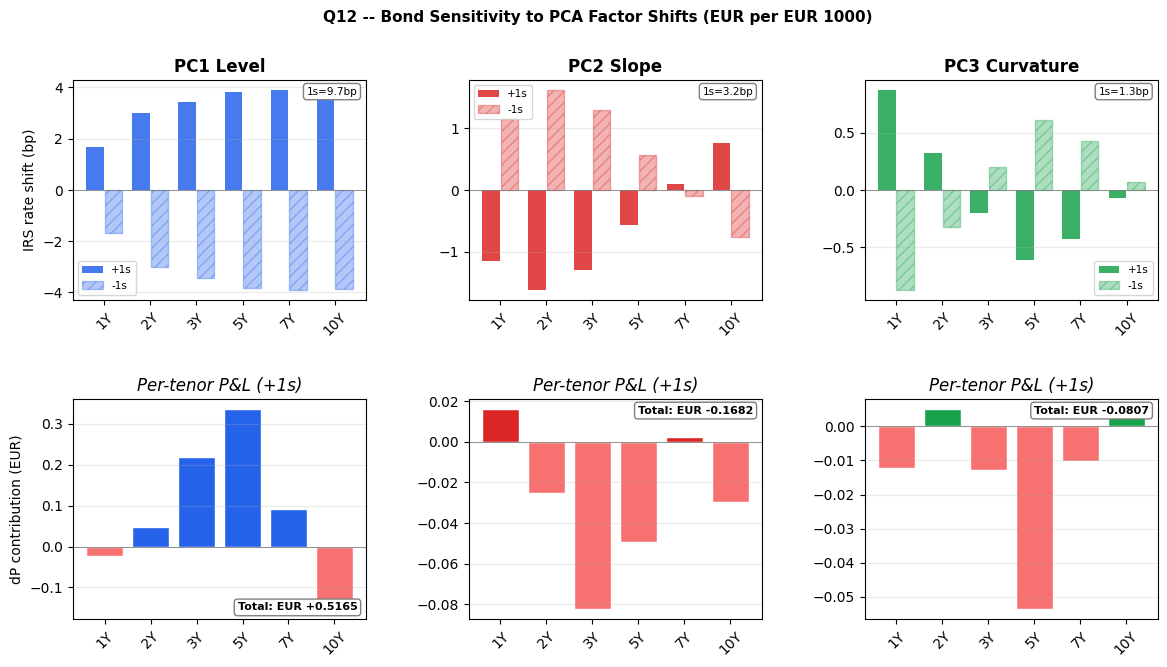

In [78]:
colors = ["#2563EB", "#DC2626", "#16A34A"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, d in enumerate(sens):
    x = np.arange(N_HEDGE)
    ax = axes[0, col]
    ax.bar(x-0.2, d["shift_plus"],  width=0.38, color=colors[col], alpha=0.85, label="+1s")
    ax.bar(x+0.2, d["shift_minus"], width=0.38, color=colors[col], alpha=0.35,
           hatch="///", edgecolor=colors[col], label="-1s")
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(LABELS_HEDGE, rotation=45)
    ax.set_title(d["name"], fontweight="bold")
    ax.set_ylabel("IRS rate shift (bp)" if col == 0 else "")
    ax.legend(fontsize=7.5); ax.grid(axis="y", alpha=0.25)
    ax.text(0.97, 0.97, f"1s={d['sigma_bp']:.1f}bp",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))
    ax2 = axes[1, col]
    bar_c = [colors[col] if v >= 0 else "#F87171" for v in d["contrib"]]
    ax2.bar(x, d["contrib"], color=bar_c, edgecolor="white")
    ax2.axhline(0, color="gray", lw=0.6)
    ax2.set_xticks(x); ax2.set_xticklabels(LABELS_HEDGE, rotation=45)
    ax2.set_ylabel("dP contribution (EUR)" if col == 0 else "")
    ax2.set_title("Per-tenor P&L (+1s)", fontstyle="italic")
    ax2.grid(axis="y", alpha=0.25)
    ypos = 0.97 if d["dP_plus"] < 0 else 0.03
    va   = "top"    if d["dP_plus"] < 0 else "bottom"
    ax2.text(0.97, ypos, f"Total: EUR {d['dP_plus']:+.4f}",
             transform=ax2.transAxes, ha="right", va=va, fontsize=8,
             fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))
fig.suptitle("Q12 -- Bond Sensitivity to PCA Factor Shifts (EUR per EUR 1000)",
             fontweight="bold", fontsize=11)
plt.subplots_adjust(hspace=0.45, wspace=0.35); plt.show()


---
## Q13: Solve for hedge notionals

Project bond and IRS DV01 vectors onto the 3 PC factor space.
Solve **Aᵀ n = −b**.

In [79]:
n_factors = 3
E = EIGVEC_HEDGE[:, :n_factors]  # (6, 3)
b = E.T @ bond_dv01_vec          # (3,) bond factor exposures
A = irs_dv01_matrix @ E          # (3, 3) hedge factor exposures

notionals, _, _, _ = np.linalg.lstsq(A.T, -b, rcond=None)
cond = np.linalg.cond(A.T)

residual_pc   = b + A.T @ notionals
residual_dv01 = bond_dv01_vec.copy()
for i, n in enumerate(notionals):
    residual_dv01 += n * irs_dv01_matrix[i]

lam3       = eigenvalues[:3]
var_before = float(b**2 @ lam3)
var_after  = float(residual_pc**2 @ lam3)
hedge_eff  = (1.0 - var_after / var_before) * 100 if var_before > 0 else 0.0

print("Q13 -- Optimal Hedge Notionals")
print(f"  Condition number of A^T: {cond:.2f}  "
      f"({'Excellent' if cond<10 else 'Good' if cond<50 else 'Check tenors'})")
print()
print(f"  {'Instrument':<24s}  {'Notional (EUR m)':>16s}  {'EUR Nominal':>14s}  Direction")
print("  " + "-"*68)
for label, n in zip(HEDGE_LABELS, notionals):
    print(f"  {label:<24s}  {n:>+16.4f}  {n*1e6:>+14,.0f}  "
          f"{'receive-fixed' if n > 0 else 'pay-fixed'}")
print()
print(f"  Hedge effectiveness (lambda-weighted variance reduction): {hedge_eff:.1f}%")
print()
print(f"  {'PC':<14s}  {'Bond exposure':>14s}  {'Portfolio exposure':>18s}")
print("  " + "-"*50)
for k, name in enumerate(["PC1 Level", "PC2 Slope", "PC3 Curvature"]):
    print(f"  {name:<14s}  {b[k]:>+14.4f}  {residual_pc[k]:>+18.2e}")


Q13 -- Optimal Hedge Notionals
  Condition number of A^T: 6.34  (Excellent)

  Instrument                Notional (EUR m)     EUR Nominal  Direction
  --------------------------------------------------------------------
  IRS 1Y                             +0.0003            +267  receive-fixed
  IRS 5Y                             +0.0004            +376  receive-fixed
  IRS 10Y                            -0.0001             -60  pay-fixed

  Hedge effectiveness (lambda-weighted variance reduction): 100.0%

  PC               Bond exposure  Portfolio exposure
  --------------------------------------------------
  PC1 Level              +0.0531           -2.78e-17
  PC2 Slope              -0.0520           +6.94e-18
  PC3 Curvature          -0.0609           -6.94e-18


---
## Q14: Implementation, residual risk, transaction costs

All quantities in Q12 and Q13 are derived per EUR 1,000 bond. The per-bond IRS notionals are small (EUR 60–376) because the structured FRN has an intrinsically low total IR DV01 of only +0.14 EUR/bp — approximately 340× lower than a fixed-rate bond of the same maturity. This is a structural property of the floating-rate mechanism, not an artefact of instrument choice.

The EUR 1m IRS minimum lot constraint is therefore evaluated at the scale of the full EUR 20m issue (20,000 bonds), which is the only practically relevant reference for whether the hedge can be implemented.

In [80]:
# N_BONDS = full issue size (20,000 bonds x EUR 1,000 = EUR 20m).
# Per-bond notionals are EUR 60-376, far below the practical EUR 1m IRS minimum lot.
# The full issue is the only scale at which this hedge becomes implementable.
N_BONDS  = 20_000
MIN_LOT  = 1_000_000

# notionals are in EUR m per bond (per EUR 1000 face).
# Total EUR notional = notionals[i] * 1_000_000 * N_BONDS.
noms_portfolio = notionals * 1_000_000 * N_BONDS
noms_rounded   = np.round(noms_portfolio / MIN_LOT) * MIN_LOT
noms_per_bond  = noms_rounded / (1_000_000 * N_BONDS)   # back to EUR m per bond

res_dv01 = bond_dv01_vec.copy()
for i, n in enumerate(noms_per_bond):
    res_dv01 += n * irs_dv01_matrix[i]
res_pc = b.copy()
for i, n in enumerate(noms_per_bond):
    res_pc += A.T[:, i] * n

print(f"Q14 -- Implementation ({N_BONDS:,} bonds / EUR {N_BONDS*1000/1e6:.0f}m portfolio)")
print()
print(f"  {'Instrument':<24s}  {'Exact (EUR m)':>14s}  {'Rounded (EUR m)':>15s}  {'Error (EUR m)':>14s}")
print("  " + "-"*73)
for label, ex, rd in zip(HEDGE_LABELS, noms_portfolio, noms_rounded):
    print(f"  {label:<24s}  {ex/1e6:>+14.2f}  {rd/1e6:>+15.2f}  {(rd-ex)/1e6:>+14.2f}")
print()
print("  Residual factor betas after rounding (per EUR 1000 bond):")
print(f"  {'Factor':<16s}  {'Bond':>10s}  {'Residual':>10s}  {'% of bond':>10s}  {'P&L 10bp':>12s}")
print("  " + "-"*62)
for k, name in enumerate(["PC1 Level", "PC2 Slope", "PC3 Curvature"]):
    res = res_pc[k]
    pct = abs(res / b[k]) * 100 if abs(b[k]) > 1e-10 else 0
    print(f"  {name:<16s}  {b[k]:>+10.4f}  {res:>+10.4f}  {pct:>9.1f}%  {res*10:>+12.4f}")

bid_ask = {1.0: 0.50, 5.0: 0.75, 10.0: 1.00}
print()
print("  Transaction costs (full issue):")
print(f"  {'Instrument':<24s}  {'Notional (EUR m)':>16s}  {'B/A (bp)':>9s}  {'Cost (EUR)':>10s}")
print("  " + "-"*65)
total_cost = 0.0
for i, (T_irs, label) in enumerate(zip(HEDGE_TENORS, HEDGE_LABELS)):
    nom  = abs(noms_rounded[i])
    ba   = bid_ask[T_irs]
    ann  = sum(P(Ti) for Ti in np.arange(1.0, T_irs + 0.01, 1.0))
    cost = nom * 0.0001 * ann * ba
    total_cost += cost
    print(f"  {label:<24s}  {nom/1e6:>+16.2f}  {ba:>9.3f}  {cost:>10.2f}")
print("  " + "-"*65)
print(f"  {'TOTAL':<24s}  {'':>16s}  {'':>9s}  {total_cost:>10.2f}")
print(f"  Cost per bond: EUR {total_cost/N_BONDS:.4f}")


Q14 -- Implementation (20,000 bonds / EUR 20m portfolio)

  Instrument                 Exact (EUR m)  Rounded (EUR m)   Error (EUR m)
  -------------------------------------------------------------------------
  IRS 1Y                             +5.34            +5.00           -0.34
  IRS 5Y                             +7.51            +8.00           +0.49
  IRS 10Y                            -1.19            -1.00           +0.19

  Residual factor betas after rounding (per EUR 1000 bond):
  Factor                  Bond    Residual   % of bond      P&L 10bp
  --------------------------------------------------------------
  PC1 Level            +0.0531     -0.0075       14.2%       -0.0754
  PC2 Slope            -0.0520     -0.0006        1.1%       -0.0058
  PC3 Curvature        -0.0609     +0.0068       11.2%       +0.0680

  Transaction costs (full issue):
  Instrument                Notional (EUR m)   B/A (bp)  Cost (EUR)
  -------------------------------------------------------

---
## Q14: Figure

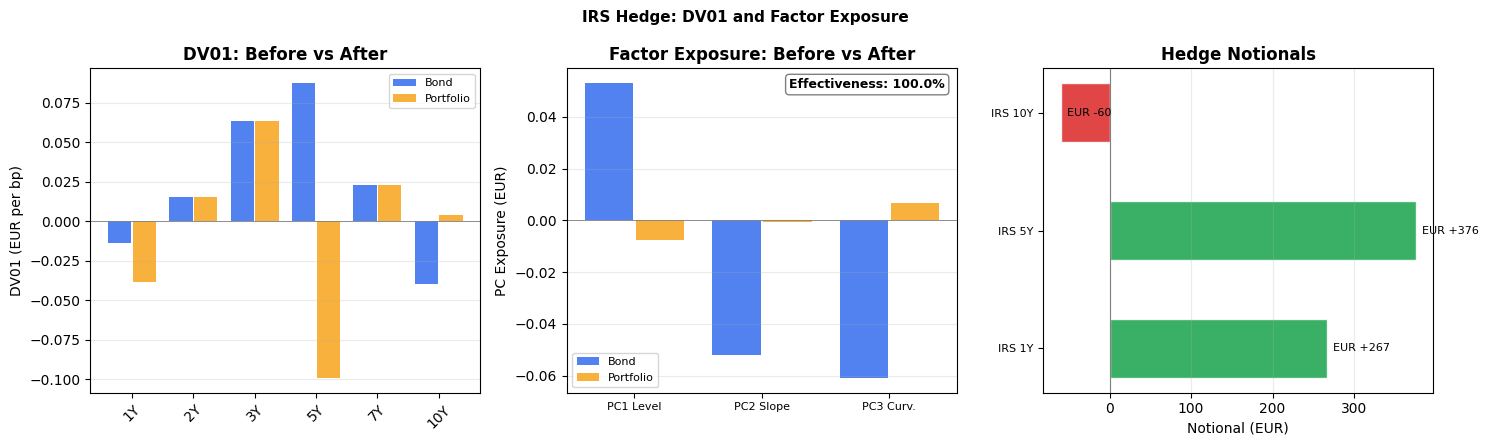

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x   = np.arange(N_HEDGE)
pcx = np.arange(n_factors)

ax = axes[0]
ax.bar(x-0.2, bond_dv01_vec, width=0.38, color="#2563EB", alpha=0.8, label="Bond")
ax.bar(x+0.2, res_dv01,      width=0.38, color="#F59E0B", alpha=0.8, label="Portfolio")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(LABELS_HEDGE, rotation=45)
ax.set_ylabel("DV01 (EUR per bp)")
ax.set_title("DV01: Before vs After", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)

ax = axes[1]
ax.bar(pcx-0.2, b,      width=0.38, color="#2563EB", alpha=0.8, label="Bond")
ax.bar(pcx+0.2, res_pc, width=0.38, color="#F59E0B", alpha=0.8, label="Portfolio")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xticks(pcx); ax.set_xticklabels(["PC1 Level","PC2 Slope","PC3 Curv."], fontsize=8)
ax.set_ylabel("PC Exposure (EUR)")
ax.set_title("Factor Exposure: Before vs After", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25)
ax.text(0.97, 0.97, f"Effectiveness: {hedge_eff:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

ax = axes[2]
bars = ax.barh(range(n_factors), notionals*1e6,
               color=["#16A34A" if v > 0 else "#DC2626" for v in notionals],
               alpha=0.85, edgecolor="white", height=0.5)
ax.axvline(0, color="gray", lw=0.8)
ax.set_yticks(range(n_factors)); ax.set_yticklabels(HEDGE_LABELS, fontsize=8)
ax.set_xlabel("Notional (EUR)")
ax.set_title("Hedge Notionals", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
offset = max(abs(notionals*1e6)) * 0.02
for bar, val in zip(bars, notionals*1e6):
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f"EUR {val:+,.0f}", va="center", fontsize=8)

plt.suptitle("IRS Hedge: DV01 and Factor Exposure",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_q13q14_hedge.pdf", bbox_inches="tight", dpi=150)
plt.show()


---
## Q14: Practical limitations

In [83]:
_min_bonds = max(int(np.ceil(MIN_LOT / (abs(n) * 1e6))) for n in notionals)
_min_eur_m = _min_bonds * 1000 / 1e6

print(f"""
Q14 -- PRACTICAL LIMITATIONS and MITIGATIONS
==============================
1. CONVEXITY: The hedge is linear. The 5.45% embedded cap adds negative
   convexity near the strike. Large moves (>50 bp) cause under-hedging.
   Mitigation: receiver swaption overlay.

2. DYNAMIC BETAS: Factor loadings shift as rates move and the bond ages.
   Mitigation: Rebalance when any factor beta drifts more than x% (e.g 10%) from target.

3. BASIS RISK (3M vs 6M EURIBOR): Bond references 3M; IRS references 6M.
   Mitigation: Use 3M EURIBOR swaps if available; otherwise.

4. SMALL NOTIONALS AND MINIMUM LOT: The bond's total IR DV01 is only
   +0.14 EUR/bp (substantially lower than a fixed-rate bond's sensitivity of the same maturity).
   This makes all hedge notionals small: EUR 267, EUR 376 and EUR 60 per
   bond for the 1Y, 5Y and 10Y swaps respectively. The EUR 1m IRS minimum
   lot is only reached at the full EUR 20m issue scale. Even then, the IRS
   10Y leg (EUR 1.2m after rounding) barely clears the threshold. For
   portfolios below EUR {_min_eur_m:.2f}m (fewer than {_min_bonds:,} bonds)
   the IRS 10Y leg cannot be implemented, and the hedge is incomplete.
   This is not a failure of the methodology — it reflects the economic
   reality that this bond has almost no interest rate risk to hedge.


5. CREDIT RISK UNHEDGED: IRS hedges only interest-rate risk. The UniCredit
   CDS spread remains fully exposed (see Q15/Q16 for the credit hedge).
""")



Q14 -- PRACTICAL LIMITATIONS and MITIGATIONS
1. CONVEXITY: The hedge is linear. The 5.45%% embedded cap adds negative
   convexity near the strike. Large moves (>50 bp) cause under-hedging.
   Mitigation: receiver swaption overlay.

2. DYNAMIC BETAS: Factor loadings shift as rates move and the bond ages.
   Mitigation: Rebalance when any factor beta drifts more than x%% (e.g 10%%) from target.

3. BASIS RISK (3M vs 6M EURIBOR): Bond references 3M; IRS references 6M.

4. SMALL NOTIONALS AND MINIMUM LOT: The bond's total IR DV01 is only
   +0.14 EUR/bp (vs ~18 EUR/bp for a fixed-rate bond of the same maturity).
   This makes all hedge notionals small: EUR 267, EUR 376 and EUR 60 per
   bond for the 1Y, 5Y and 10Y swaps respectively. The EUR 1m IRS minimum
   lot is only reached at the full EUR 20m issue scale. Even then, the IRS
   10Y leg (EUR 1.2m after rounding) barely clears the threshold. For
   portfolios below EUR 16.77m (fewer than 16,771 bonds)
   the IRS 10Y leg cannot be impl